# Pertemuan 11  
## Dokumentasi Implementasi Klasifikasi Decision Tree Menggunakan KNIME Analytics Platform

Dokumen ini menjelaskan kembali proses pembuatan model klasifikasi menggunakan algoritma **Decision Tree** pada aplikasi **KNIME Analytics Platform**. Penjelasan dibuat dengan bahasa yang berbeda, tetapi inti pembahasan dan hasil akhirnya tetap sama, yaitu memahami alur kerja mulai dari membaca data, membagi data, membangun model, melakukan prediksi, hingga mengevaluasi performa model.



## 1. Gambaran Umum Workflow

Workflow yang digunakan merupakan penerapan dari metode **Supervised Learning**, yaitu pembelajaran mesin yang menggunakan data berlabel sebagai acuan untuk melatih model. Pada proses ini, data tidak langsung digunakan seluruhnya untuk pelatihan, melainkan dipisahkan menjadi dua bagian, yaitu **data training** dan **data testing**.

Pembagian data ini penting agar model tidak hanya menghafal data yang sudah ada, tetapi juga dapat diuji kemampuannya dalam memprediksi data baru. Dengan cara ini, performa model dapat dinilai secara lebih objektif dan risiko **overfitting** dapat diketahui.
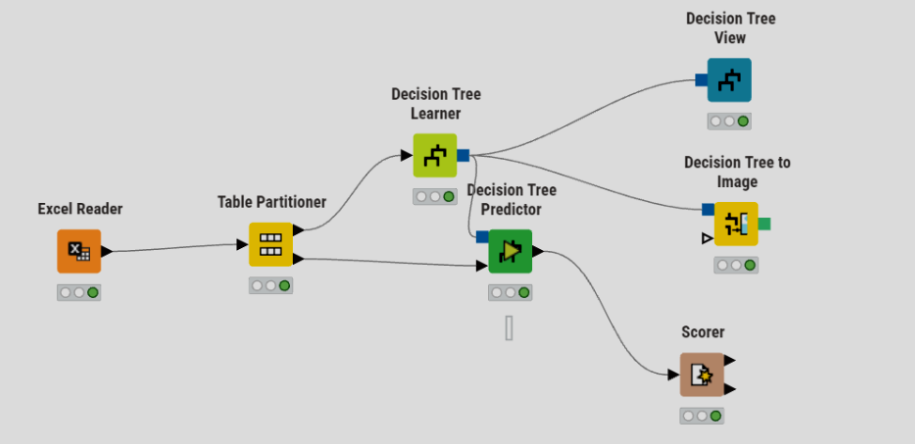

Secara umum, alur workflow berjalan secara berurutan dari tahap input data sampai tahap evaluasi hasil prediksi. Setiap node dalam KNIME harus berhasil dijalankan atau berada pada status **Executed** agar output yang dihasilkan valid.




## 2. Komponen Workflow dan Fungsinya

Berikut adalah penjelasan dari setiap node yang digunakan dalam workflow Decision Tree.

### 2.1 Excel Reader

Node **Excel Reader** digunakan untuk membaca dataset dari file Excel, yaitu `Play_Tennis_Dataset.xlsx`.

Pada tahap ini, KNIME mengambil data dari file sumber dan mengenali struktur kolom yang ada di dalam dataset. Dataset yang digunakan memiliki beberapa atribut prediktor seperti:

- Outlook  
- Temp  
- Humidity  
- Wind  

Selain itu, terdapat kolom target, misalnya **Play Tennis**, yang menjadi label kelas untuk proses klasifikasi.

Hal penting yang perlu diperhatikan adalah tipe data pada kolom target. Kolom target sebaiknya bertipe **String** karena akan digunakan sebagai kelas dalam proses klasifikasi. Jika kolom tersebut terbaca sebagai numerik, maka tipe datanya perlu diubah terlebih dahulu sebelum masuk ke node pembelajaran model.



### 2.2 Table Partitioner

Node **Table Partitioner** berfungsi untuk membagi dataset menjadi dua bagian, yaitu:

1. **Training Set**  
   Digunakan untuk melatih model Decision Tree.

2. **Testing Set**  
   Digunakan untuk menguji hasil prediksi dari model yang telah dilatih.

Konfigurasi pembagian data yang digunakan adalah **80:20**, artinya 80% data digunakan sebagai data training dan 20% sisanya digunakan sebagai data testing.

Agar distribusi kelas pada data training dan testing tetap seimbang, metode yang disarankan adalah **Stratified Sampling** berdasarkan kolom target. Dengan metode ini, proporsi kelas pada kedua subset data tetap terjaga.



### 2.3 Decision Tree Learner

Node **Decision Tree Learner** merupakan bagian utama dalam proses pembentukan model. Node ini mempelajari hubungan antara atribut input seperti `Outlook`, `Temp`, `Humidity`, dan `Wind` terhadap target klasifikasi, yaitu `Play Tennis`.

Model Decision Tree bekerja dengan membentuk struktur pohon keputusan. Setiap cabang pada pohon menunjukkan aturan tertentu, sedangkan daun pohon menunjukkan hasil keputusan atau kelas akhir.

Dalam menentukan atribut terbaik untuk pemisahan data, algoritma dapat menggunakan ukuran seperti:

- **Gini Index**
- **Information Gain**

Atribut yang memiliki kemampuan paling baik dalam memisahkan kelas akan dipilih sebagai node pemisah. Pengaturan seperti kedalaman pohon atau jumlah minimum data pada tiap node juga dapat disesuaikan untuk menghasilkan model yang lebih baik dan tidak terlalu kompleks.



### 2.4 Decision Tree Predictor

Node **Decision Tree Predictor** digunakan untuk menerapkan model yang sudah dibuat pada data testing. Data testing merupakan data yang belum digunakan pada proses pelatihan, sehingga dapat digunakan untuk mengetahui kemampuan model dalam memprediksi data baru.

Output dari node ini adalah tabel yang berisi data asli dan tambahan kolom prediksi, misalnya:

`Prediction (Play Tennis)`

Kolom tersebut menunjukkan hasil prediksi model terhadap setiap baris data testing.



### 2.5 Scorer

Node **Scorer** digunakan untuk mengevaluasi hasil prediksi model. Node ini membandingkan nilai aktual pada dataset dengan hasil prediksi yang dihasilkan oleh model Decision Tree.

Output utama dari node Scorer adalah **Confusion Matrix**. Confusion Matrix menunjukkan jumlah data yang berhasil diprediksi dengan benar dan jumlah data yang salah diprediksi.

Dari hasil ini, performa model dapat dianalisis secara kuantitatif.



## 3. Visualisasi dan Interpretasi Decision Tree

Visualisasi pohon keputusan digunakan untuk melihat bagaimana model mengambil keputusan. Dengan adanya visualisasi ini, pengguna dapat memahami aturan-aturan yang terbentuk dari proses pembelajaran.

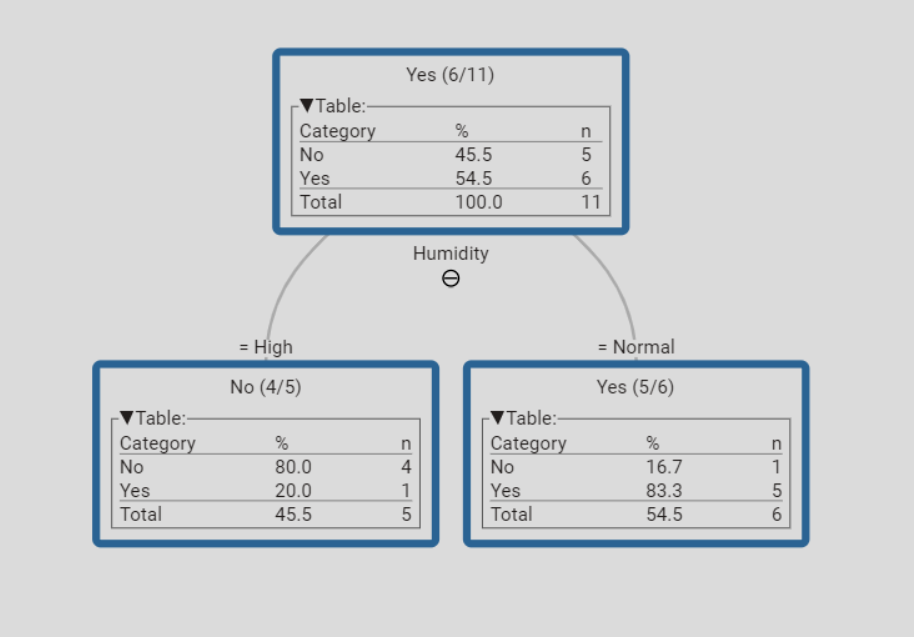

Node paling atas pada pohon disebut **Root Node**. Root Node menunjukkan atribut yang dianggap paling berpengaruh dalam menentukan hasil klasifikasi. Semakin dekat suatu atribut ke bagian atas pohon, semakin besar perannya dalam proses pengambilan keputusan.

Visualisasi pohon dapat diakses pada KNIME melalui:

**Klik kanan pada Decision Tree View → Interactive View**

Melalui tampilan tersebut, struktur pohon dapat diamati dengan lebih jelas sehingga proses klasifikasi menjadi lebih mudah dipahami.



## 4. Evaluasi Performa Model

Untuk menilai kualitas model, digunakan metrik **akurasi**. Akurasi menunjukkan persentase jumlah prediksi yang benar dibandingkan dengan seluruh data testing.

Rumus akurasi adalah:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Keterangan:

- **TP (True Positive)**: data positif yang diprediksi benar sebagai positif  
- **TN (True Negative)**: data negatif yang diprediksi benar sebagai negatif  
- **FP (False Positive)**: data negatif yang salah diprediksi sebagai positif  
- **FN (False Negative)**: data positif yang salah diprediksi sebagai negatif  

Semakin tinggi nilai akurasi, semakin baik kemampuan model dalam melakukan klasifikasi. Selain akurasi, metrik lain seperti **Precision** dan **Recall** juga dapat digunakan untuk memahami performa model secara lebih lengkap.

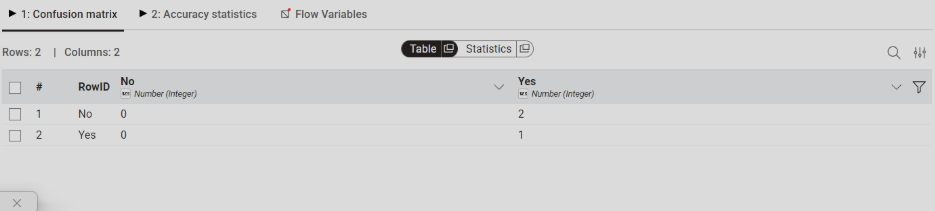

## 5. Kesimpulan

Berdasarkan implementasi workflow Decision Tree pada KNIME, dapat disimpulkan bahwa algoritma Decision Tree mampu digunakan untuk melakukan klasifikasi pada dataset `Play_Tennis_Dataset.xlsx`.

Workflow dimulai dari proses membaca data menggunakan **Excel Reader**, membagi data menggunakan **Table Partitioner**, membangun model dengan **Decision Tree Learner**, melakukan prediksi menggunakan **Decision Tree Predictor**, dan mengevaluasi hasil dengan **Scorer**.

Hasil visualisasi pohon keputusan membantu pengguna memahami aturan klasifikasi yang terbentuk, sedangkan Confusion Matrix dan nilai akurasi memberikan gambaran kuantitatif mengenai performa model.

Dengan demikian, Decision Tree pada KNIME dapat menjadi metode yang efektif untuk mengidentifikasi pola pada data dan menghasilkan prediksi berdasarkan atribut-atribut yang tersedia.
